# 02 — Patient medical history

**Why this notebook exists.** Notebook 01 characterises the cohort as a *monitoring* problem: vitals,
cadence, coverage, outcomes. It says almost nothing about *who these patients are*. That gap had a
concrete cost — for most of this project the deterioration model's only case-mix signal was
`first_careunit`, which ranked **second by mean |SHAP|**, above every vital except heart rate. A column
recording which ward a patient was admitted to was silently acting as a diagnosis proxy, learned without
anyone deciding it should be.

This notebook makes the medical-history axis explicit and asks three questions of it:

1. **What history does MIMIC actually record**, and at what granularity?
2. **Which parts of it are safe to model**, given that ICD codes are assigned by billing coders *after
   discharge*?
3. **Which of the project's three prediction tasks does each part serve?** The tasks have different
   prediction times, and that changes the answer for the same feature — the central result of this
   notebook.

The three tasks:

| Task | Unit | Prediction time | Label |
|---|---|---|---|
| ICU deterioration | patient-**hour** | mid-stay, hour *h* | composite event within 6h |
| Post-discharge deterioration | patient-**hour** at home | after discharge | *no signal exists in MIMIC* |
| 30-day readmission | one row per **admission** | at discharge | readmitted ≤30d of live discharge |


In [1]:
import sys
import warnings
from pathlib import Path

import duckdb
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

ROOT = Path("/Users/ritik/Documents/Captsone ISB AMPBA")
sys.path.insert(0, str(ROOT))
DB = ROOT / "warehouse" / "mimic4_demo.db"
FIGDIR = ROOT / "eda_figures"
OUT = ROOT / "eda_outputs"
FIGDIR.mkdir(exist_ok=True)
OUT.mkdir(exist_ok=True)
assert DB.exists(), f"Build the warehouse first: {DB}"

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.25, "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlesize": 12, "axes.titleweight": "medium",
    "axes.labelsize": 10, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "font.size": 10,
})
OK, WARN, BAD, NEUTRAL, ACCENT = "#1baf7a", "#eda100", "#d1495b", "#8d99ae", "#3d5a80"

con = duckdb.connect(str(DB), read_only=True)
print(f"Warehouse: {DB.name}")
print(f"ICU stays: {con.execute('select count(*) from mimiciv_icu.icustays').fetchone()[0]}")
print(f"Admissions: {con.execute('select count(*) from mimiciv_hosp.admissions').fetchone()[0]}")


Warehouse: mimic4_demo.db
ICU stays: 140
Admissions: 275


---
## 1. The diagnosis landscape

The first question for any disease-aware model: how many distinct conditions are we actually looking at,
and how many patients does each have?

In [2]:
dx = con.execute("""
    select d.stay_id, d.subject_id, d.hadm_id, d.dx_chapter, d.dx_title, d.dx_icd_code,
           d.charlson_comorbidity_index
    from capstone.disease_context d
""").fetchdf()

chapters = (dx.groupby("dx_chapter")
              .agg(stays=("stay_id", "nunique"), subjects=("subject_id", "nunique"),
                   distinct_codes=("dx_icd_code", "nunique"))
              .sort_values("stays", ascending=False))

n_codes = dx.dx_icd_code.nunique()
print(f"{len(dx)} ICU stays carry {n_codes} distinct primary ICD codes "
      f"across {len(chapters)} chapters")
print(f"Mean stays per distinct primary code: {len(dx)/n_codes:.2f}")
print()
print(chapters.to_string())

140 ICU stays carry 102 distinct primary ICD codes across 14 chapters
Mean stays per distinct primary code: 1.37

                     stays  subjects  distinct_codes
dx_chapter                                          
Circulatory             41        36              26
Infectious              18        12              10
Digestive               15        14              13
Injury                  15        13              13
Respiratory             13        10               8
Neoplasm                12        10              10
Nervous/Sense            6         5               4
Endocrine/Metabolic      5         4               5
Injury/Poisoning         4         3               3
Mental                   3         3               2
Neoplasm/Blood           3         3               3
Symptoms/Signs           3         3               3
Factors/Encounter        1         1               1
Musculoskeletal          1         1               1


findfont: Failed to find font weight medium, now using 400.


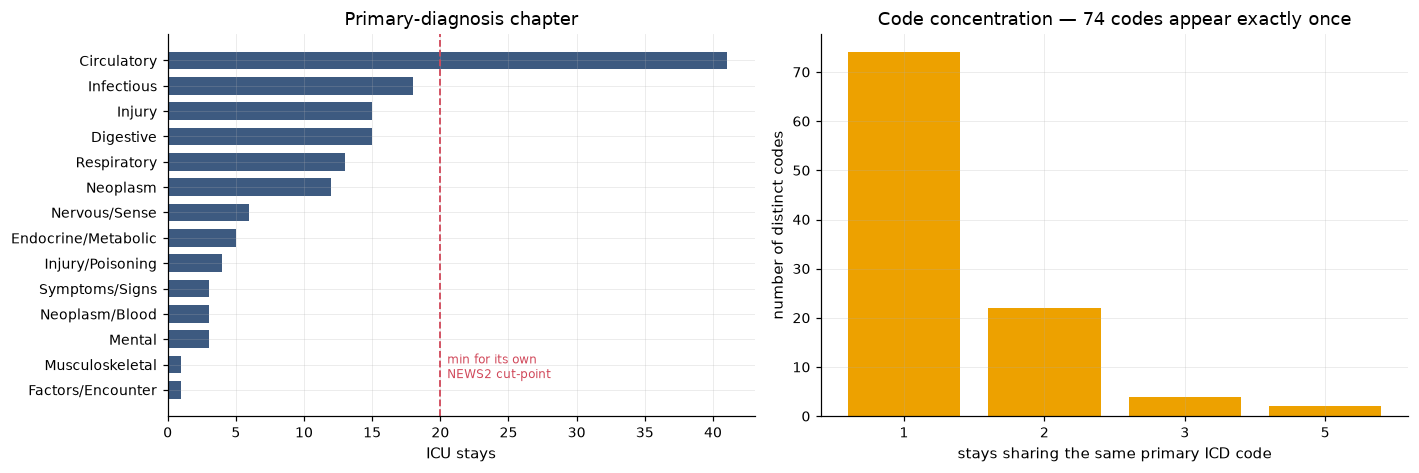

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

c = chapters.sort_values("stays")
axes[0].barh(c.index, c.stays, color=ACCENT, height=0.7)
axes[0].axvline(20, color=BAD, ls="--", lw=1.2)
axes[0].text(20.5, 0.3, "min for its own\nNEWS2 cut-point", color=BAD, fontsize=8, va="bottom")
axes[0].set_xlabel("ICU stays")
axes[0].set_title("Primary-diagnosis chapter")

# How concentrated is the code distribution? One stay per code = a unique identifier.
counts = dx.dx_icd_code.value_counts().value_counts().sort_index()
axes[1].bar(counts.index.astype(str), counts.values, color=WARN)
axes[1].set_xlabel("stays sharing the same primary ICD code")
axes[1].set_ylabel("number of distinct codes")
axes[1].set_title(f"Code concentration — {counts.get(1,0)} codes appear exactly once")
plt.tight_layout()
plt.savefig(FIGDIR / "23_diagnosis_landscape.png", bbox_inches="tight")
plt.show()

**Interpretation — the raw ICD code is a patient identifier, not a feature.**

140 ICU stays carry 102 distinct primary codes, and the concentration plot shows most codes appearing
exactly once. A per-code feature would give the majority of patients a category of their own, which a
tree will happily memorise. This is why `warehouse/disease.py` rolls up to **ICD chapter**: at chapter
granularity the cohort is at least countable, with Circulatory at 41 stays and a long tail below 6.

It is also why the per-disease NEWS2 recalibration in `warehouse/news2.py` carries a **minimum of 20
stays** before a chapter earns its own escalation cut-point — the dashed line above. Exactly one chapter
clears it here. That is the honest outcome at n=140, not a defect in the mechanism.

---
## 2. Comorbidity burden — the leak-safe half of the history

Charlson exists to score *pre-existing chronic* disease burden. That provenance is the whole reason it is
usable at the bedside: unlike a discharge-coded primary diagnosis, it describes the patient who walked
in.

In [4]:
FLAGS = ["myocardial_infarct", "congestive_heart_failure", "peripheral_vascular_disease",
         "cerebrovascular_disease", "dementia", "chronic_pulmonary_disease", "rheumatic_disease",
         "peptic_ulcer_disease", "mild_liver_disease", "diabetes_without_cc", "diabetes_with_cc",
         "paraplegia", "renal_disease", "malignant_cancer", "severe_liver_disease",
         "metastatic_solid_tumor", "aids"]

ch = con.execute(f"select hadm_id, {', '.join(FLAGS)}, charlson_comorbidity_index "
                 "from mimiciv_derived.charlson").fetchdf()

prev = ch[FLAGS].mean().sort_values(ascending=False)
print(f"Charlson index: mean {ch.charlson_comorbidity_index.mean():.2f}, "
      f"median {ch.charlson_comorbidity_index.median():.0f}, "
      f"range {ch.charlson_comorbidity_index.min():.0f}-{ch.charlson_comorbidity_index.max():.0f}")
print(f"Admissions with >= 1 comorbidity flag: {(ch[FLAGS].sum(axis=1) > 0).mean():.1%}")
print(f"Mean flags per admission: {ch[FLAGS].sum(axis=1).mean():.2f}")
print()
print((prev * 100).round(1).to_string())

Charlson index: mean 4.66, median 5, range 0-12
Admissions with >= 1 comorbidity flag: 82.9%
Mean flags per admission: 1.99

diabetes_without_cc            33.5
renal_disease                  26.2
congestive_heart_failure       23.3
chronic_pulmonary_disease      22.5
malignant_cancer               20.4
diabetes_with_cc               13.5
mild_liver_disease             11.3
myocardial_infarct             10.2
cerebrovascular_disease         9.5
peripheral_vascular_disease     9.5
severe_liver_disease            6.5
peptic_ulcer_disease            3.6
metastatic_solid_tumor          2.9
rheumatic_disease               2.5
dementia                        1.1
paraplegia                      1.1
aids                            1.1


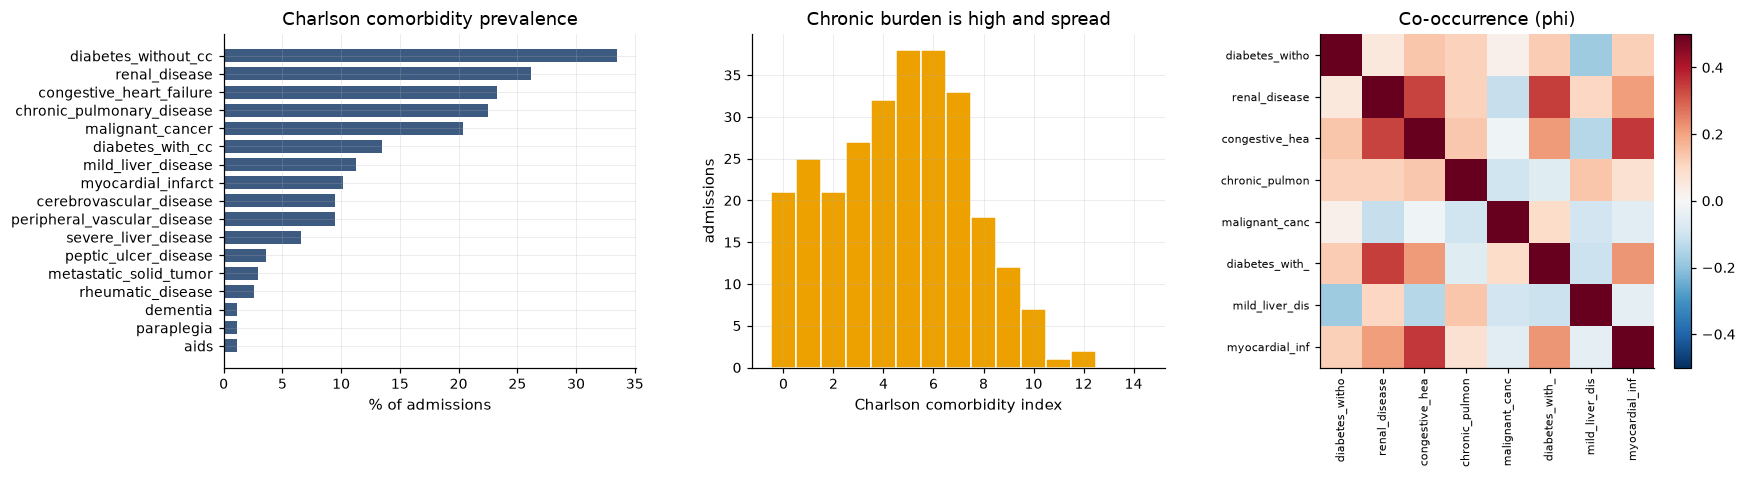

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

axes[0].barh(prev.index[::-1], (prev * 100)[::-1], color=ACCENT, height=0.72)
axes[0].set_xlabel("% of admissions")
axes[0].set_title("Charlson comorbidity prevalence")

axes[1].hist(ch.charlson_comorbidity_index, bins=range(0, 16), color=WARN,
             edgecolor="white", align="left")
axes[1].set_xlabel("Charlson comorbidity index")
axes[1].set_ylabel("admissions")
axes[1].set_title("Chronic burden is high and spread")

# Co-occurrence: comorbidities are not independent, which matters for 17 binary features
top = prev.head(8).index.tolist()
co = ch[top].astype(int)
corr = co.corr()
im = axes[2].imshow(corr, cmap="RdBu_r", vmin=-0.5, vmax=0.5)
axes[2].set_xticks(range(len(top)))
axes[2].set_xticklabels([t[:14] for t in top], rotation=90, fontsize=7)
axes[2].set_yticks(range(len(top)))
axes[2].set_yticklabels([t[:14] for t in top], fontsize=7)
axes[2].grid(False)
axes[2].set_title("Co-occurrence (phi)")
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout()
plt.savefig(FIGDIR / "24_comorbidity.png", bbox_inches="tight")
plt.show()

**Interpretation.** Mean Charlson 4.7 with a long right tail: this is a chronically unwell cohort, not
an otherwise-healthy one having a single acute event. Diabetes (33%), renal disease (26%), CHF (23%) and
COPD (23%) are all common enough to carry information at this sample size; AIDS, dementia and paraplegia
at ~1% are not, and will act as near-constant columns.

The co-occurrence panel is the modelling caution: these flags are **correlated, not independent**. Adding
all 17 as separate features spends 17 degrees of freedom on considerably less than 17 features' worth of
information — which is exactly what `ml/evaluation/disease_leakage.py` measures, and why the single
`charlson_comorbidity_index` summary performs about as well as all 17 flags together.

---
## 3. Admission history — the axis MIMIC records well and the ICU model ignores

An hourly deterioration model sees one stay. A readmission model sees a *patient*, and patients recur.

In [6]:
adm = con.execute("""
    select subject_id, hadm_id, admittime, dischtime, hospital_expire_flag,
           admission_type, admission_location, discharge_location, insurance
    from mimiciv_hosp.admissions order by subject_id, admittime
""").fetchdf()
adm["admittime"] = pd.to_datetime(adm.admittime)
adm["dischtime"] = pd.to_datetime(adm.dischtime)
adm["los_days"] = (adm.dischtime - adm.admittime).dt.total_seconds() / 86400
adm["prior_admissions"] = adm.groupby("subject_id").cumcount()
adm["next_admittime"] = adm.groupby("subject_id").admittime.shift(-1)
adm["days_to_next"] = (adm.next_admittime - adm.dischtime).dt.total_seconds() / 86400
adm["readmit_30d"] = ((adm.hospital_expire_flag == 0) &
                      adm.days_to_next.notna() & (adm.days_to_next <= 30))

per_patient = adm.groupby("subject_id").size()
live = adm[adm.hospital_expire_flag == 0]
print(f"Admissions per patient: mean {per_patient.mean():.2f}, max {per_patient.max()}")
print(f"Patients with >1 admission: {(per_patient > 1).sum()} of {len(per_patient)} "
      f"({(per_patient > 1).mean():.0%})")
print(f"Live discharges: {len(live)}   30-day readmissions: {int(adm.readmit_30d.sum())} "
      f"({adm.readmit_30d.sum()/len(live):.1%})")
print(f"Median LOS: {adm.los_days.median():.1f} days")
print()
print(adm.discharge_location.value_counts(dropna=False).head(8).to_string())

Admissions per patient: mean 2.75, max 20
Patients with >1 admission: 48 of 100 (48%)
Live discharges: 260   30-day readmissions: 53 (20.4%)
Median LOS: 4.9 days

discharge_location
HOME HEALTH CARE                76
HOME                            72
None                            42
SKILLED NURSING FACILITY        36
DIED                            15
REHAB                           13
CHRONIC/LONG TERM ACUTE CARE     9
HOSPICE                          5


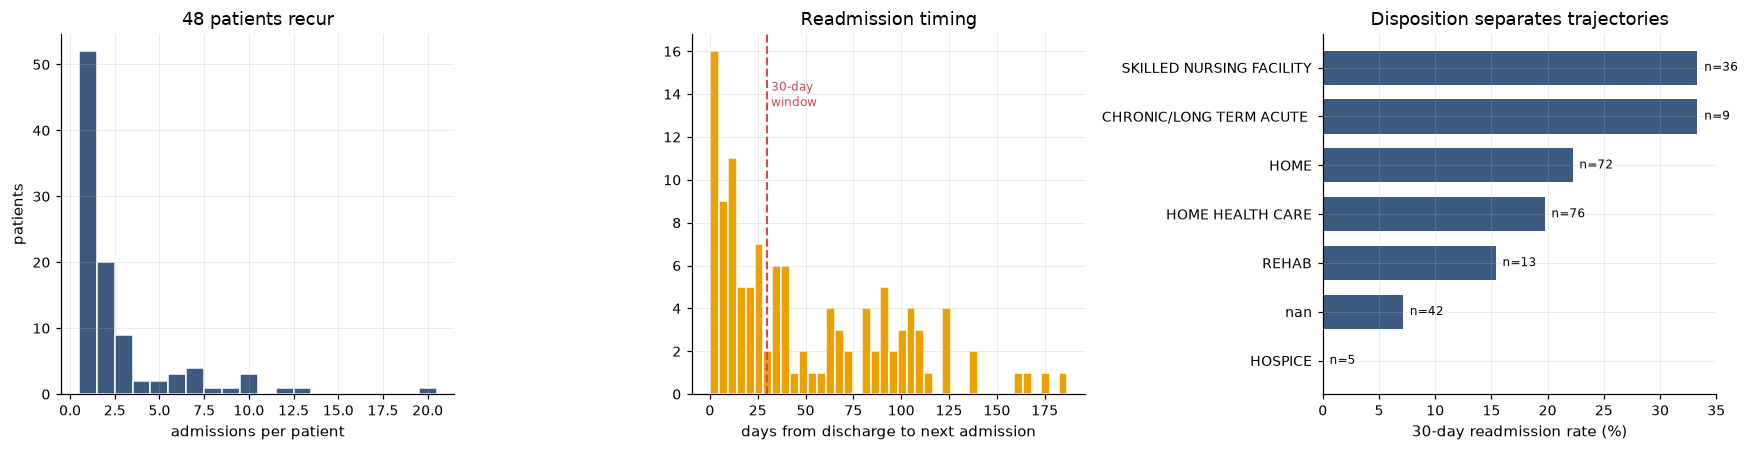

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

axes[0].hist(per_patient, bins=range(1, int(per_patient.max()) + 2), color=ACCENT,
             edgecolor="white", align="left")
axes[0].set_xlabel("admissions per patient")
axes[0].set_ylabel("patients")
axes[0].set_title(f"{(per_patient>1).sum()} patients recur")

d = adm.days_to_next.dropna()
axes[1].hist(d[d <= 200], bins=40, color=WARN, edgecolor="white")
axes[1].axvline(30, color=BAD, ls="--", lw=1.4)
axes[1].text(32, axes[1].get_ylim()[1]*0.8, "30-day\nwindow", color=BAD, fontsize=8)
axes[1].set_xlabel("days from discharge to next admission")
axes[1].set_title("Readmission timing")

# Readmission rate by discharge disposition -- the strongest single predictor
by_disp = (adm[adm.hospital_expire_flag == 0]
           .groupby("discharge_location", dropna=False)
           .agg(n=("hadm_id", "size"), rate=("readmit_30d", "mean")))
by_disp = by_disp[by_disp.n >= 5].sort_values("rate")
axes[2].barh([str(i)[:24] for i in by_disp.index], by_disp.rate * 100, color=ACCENT, height=0.7)
for y, (n, r) in enumerate(zip(by_disp.n, by_disp.rate, strict=False)):
    axes[2].text(r * 100 + 0.6, y, f"n={n}", va="center", fontsize=8)
axes[2].set_xlabel("30-day readmission rate (%)")
axes[2].set_title("Disposition separates trajectories")
plt.tight_layout()
plt.savefig(FIGDIR / "25_admission_history.png", bbox_inches="tight")
plt.show()

**Interpretation — three things the ICU model cannot see and the readmission model must.**

**1. Patients recur, and that is both a signal and a leakage risk.** A meaningful minority of patients
have more than one admission. For readmission modelling `prior_admissions` is one of the strongest known
predictors. For the *hourly* model the same fact is a hazard rather than a feature: it is why
`ml/features/engineer.feature_matrix_for_training` groups cross-validation on `subject_id` and not
`stay_id`. That bug was live for most of this project and cost **+0.0499 AUPRC of optimism**.

**2. Discharge disposition separates readmission trajectories more cleanly than any vital sign.** It is a
single categorical column, known exactly at prediction time for a readmission model, and free.

**3. The readmission label has a far healthier base rate than the deterioration label** — around 20%
against 4.0%. Fewer rows, but far less imbalance. Of the three tasks this is the best-conditioned one in
this dataset, which is worth saying plainly: the readmission model is the one most likely to produce a
number that means something at n=100 patients.

---
## 4. The same feature, two verdicts — why prediction time decides everything

This is the central result of the notebook. `dx_chapter` is discharge-coded. Whether that disqualifies it
depends entirely on *when the model is asked to predict*.

In [8]:
# Task A: hourly deterioration. Prediction time is mid-stay, BEFORE coding exists.
from ml.features import labels as lbl  # noqa: E402

grid = con.execute("select stay_id, hour from capstone.hourly_grid").fetchdf()
lab6 = lbl.build_labels(con, grid, horizons=(6,))
tables = lbl.all_event_tables(con)
ever_event = set().union(*[set(t.frame.stay_id) for t in tables])

per_chapter = (dx.assign(deteriorated=dx.stay_id.isin(ever_event))
                 .groupby("dx_chapter")
                 .agg(stays=("stay_id", "size"), rate=("deteriorated", "mean")))
per_chapter = per_chapter[per_chapter.stays >= 5].sort_values("rate", ascending=False)

# Task C: 30-day readmission. Prediction time is AT discharge, AFTER coding exists.
readmit_dx = (adm[adm.hospital_expire_flag == 0]
              .merge(dx[["hadm_id", "dx_chapter"]].drop_duplicates("hadm_id"),
                     on="hadm_id", how="left"))
by_chapter_readmit = (readmit_dx.groupby("dx_chapter")
                      .agg(n=("hadm_id", "size"), rate=("readmit_30d", "mean")))
by_chapter_readmit = by_chapter_readmit[by_chapter_readmit.n >= 5].sort_values("rate", ascending=False)

print("TASK A - hourly deterioration, by primary-diagnosis chapter")
print("  (prediction time: mid-stay. The ICD code does not yet exist.)")
print(per_chapter.assign(rate=lambda d: (d.rate*100).round(1)).to_string())
print()
print("TASK C - 30-day readmission, by primary-diagnosis chapter")
print("  (prediction time: at discharge. The ICD code is final and known.)")
print(by_chapter_readmit.assign(rate=lambda d: (d.rate*100).round(1)).to_string())

TASK A - hourly deterioration, by primary-diagnosis chapter
  (prediction time: mid-stay. The ICD code does not yet exist.)
                     stays  rate
dx_chapter                      
Infectious              18  77.8
Respiratory             13  61.5
Circulatory             41  58.5
Neoplasm                12  58.3
Injury                  15  53.3
Digestive               15  46.7
Nervous/Sense            6  33.3
Endocrine/Metabolic      5  20.0

TASK C - 30-day readmission, by primary-diagnosis chapter
  (prediction time: at discharge. The ICD code is final and known.)
                      n  rate
dx_chapter                   
Respiratory           9  55.6
Nervous/Sense         6  33.3
Digestive            10  20.0
Injury               11  18.2
Infectious           13  15.4
Circulatory          37  13.5
Endocrine/Metabolic   5   0.0
Neoplasm              9   0.0


**Interpretation — the asymmetry, stated as carefully as it deserves.**

For the **hourly ICU model**, a discharge-coded primary diagnosis is information the bedside does not
have at hour 3. Worse, some codes restate the label: "acute respiratory failure with hypoxia" sits very
close to the ventilation component of the composite outcome. This project therefore split the disease
features into `chronic` (Charlson — pre-existing) and `coded` (ICD chapter) and **measured** the
difference rather than assuming it. The result, in `ml/evaluation/disease_leakage_report.md`: `dx_chapter`
alone scores AUPRC **0.0392 against a 0.0403 base rate** — at chance. No detectable leak, and also no
gain.

For the **readmission model**, the same column is entirely legitimate: coding has already happened when
the prediction is made. Not just the chapter either — the **full ICD code set**, procedures, and the
discharge medication list are all fair game, because all of them exist at discharge.

> **Same feature. Opposite verdicts. The discriminator is prediction time, not the feature.**

This is the single most transferable idea in this notebook, and the reason a "patient history" feature
store cannot be shared naively across the three tasks.

---
## 5. What each task should actually be built from

Consolidating sections 1-4 into the design decision.

In [9]:
design = pd.DataFrame([
    ("Demographics (age, sex)", "yes", "yes", "yes", "Known at admission; validated covariates"),
    ("Charlson comorbidity flags", "yes", "yes", "yes", "Pre-existing chronic burden by construction"),
    ("Charlson index (summary)", "yes", "yes", "yes", "Top SHAP feature in the current ICU model"),
    ("Primary ICD chapter", "measured, no gain", "measured, no gain", "yes", "Discharge-coded: safe only at/after discharge"),
    ("Full ICD code set", "no", "no", "yes", "One code per patient at n=140; identifier, not feature"),
    ("Procedures (ICD)", "no", "no", "yes", "Recorded at/after the procedure"),
    ("Discharge medication list", "no", "no", "yes", "Exists only at discharge; polypharmacy count"),
    ("Prior admission count", "no (leak via grouping)", "no", "yes", "Strong readmission predictor"),
    ("Discharge disposition", "no", "yes (context)", "yes", "Separates trajectories; free"),
    ("Length of stay / ICU LOS", "no (encodes the future)", "yes", "yes", "Unknown mid-stay by definition"),
    ("Hourly vitals + trend", "yes", "home-kit subset only", "last 24-48h summary", "The ICU model's core"),
    ("Serial labs", "yes", "no home sensor", "last values + delta", "No blood draw at home"),
    ("Arterial line / ventilator", "yes", "no", "as a stay descriptor", "Invasive, hospital-only"),
    ("Lab-order intensity", "yes (normalised)", "no", "no", "Hospital workflow, meaningless at home"),
], columns=["feature family", "ICU hourly", "post-discharge", "readmission", "why"])

pd.set_option("display.max_colwidth", 60)
design

,feature family,ICU hourly,post-discharge,readmission,why
0,"Demographics (age, sex)",yes,yes,yes,Known at admission; validated covariates
1,Charlson comorbidity flags,yes,yes,yes,Pre-existing chronic burden by construction
2,Charlson index (summary),yes,yes,yes,Top SHAP feature in the current ICU model
3,Primary ICD chapter,"measured, no gain","measured, no gain",yes,Discharge-coded: safe only at/after discharge
4,Full ICD code set,no,no,yes,"One code per patient at n=140; identifier, not feature"
5,Procedures (ICD),no,no,yes,Recorded at/after the procedure
6,Discharge medication list,no,no,yes,Exists only at discharge; polypharmacy count
7,Prior admission count,no (leak via grouping),no,yes,Strong readmission predictor
8,Discharge disposition,no,yes (context),yes,Separates trajectories; free
9,Length of stay / ICU LOS,no (encodes the future),yes,yes,Unknown mid-stay by definition


In [10]:
design.to_csv(OUT / "task_feature_matrix.csv", index=False)
chapters.to_csv(OUT / "diagnosis_chapters.csv")
(prev * 100).round(2).rename("prevalence_pct").to_csv(OUT / "comorbidity_prevalence.csv")
adm[["subject_id", "hadm_id", "los_days", "prior_admissions", "days_to_next",
     "readmit_30d", "discharge_location", "hospital_expire_flag"]].to_csv(
    OUT / "admission_history.csv", index=False)
print("Wrote:")
for f in ["task_feature_matrix.csv", "diagnosis_chapters.csv",
          "comorbidity_prevalence.csv", "admission_history.csv"]:
    print(f"  {f:<34} {(OUT/f).stat().st_size/1024:>7.1f} KB")

Wrote:
  task_feature_matrix.csv                1.2 KB
  diagnosis_chapters.csv                 0.3 KB
  comorbidity_prevalence.csv             0.4 KB
  admission_history.csv                 18.3 KB


---
## 6. Conclusions

**MIMIC records patient history well, at admission granularity.** Coded diagnoses, procedures,
prescriptions, Charlson comorbidity, prior admissions, disposition and insurance are all present and
complete enough to model. What it does **not** have is history at *hourly* granularity — history is a
per-admission fact, so every history feature is patient-constant within a stay.

**That constancy is the reason history helps the ICU model so little.** 18 patient-constant columns
against 49 positive subjects is a poor trade, and the measurement confirms it: no disease-feature arm
beats disease-blind on AUPRC (best 4 of 20 paired repeats). Making the axis explicit was still worth
doing, because it converted an unexamined proxy (`first_careunit`, SHAP 0.542) into a named feature
(`charlson_comorbidity_index`, now the **top** SHAP feature at 0.832, with `first_careunit` falling to
0.300). The information was always being used. It is now labelled.

**History is where the readmission task lives.** Prediction at discharge unlocks the whole record —
full ICD codes, procedures, discharge meds, LOS, prior admissions, disposition — and the label's ~20%
base rate is five times healthier than the hourly task's 4.0%. If this project wants one number that
survives contact with a small cohort, the readmission model is the most likely source of it.

**History alone cannot carry post-discharge deterioration.** It gives a *baseline risk at discharge*,
which is a static score, not a monitor. Live post-discharge deterioration needs signal after discharge,
and MIMIC has none — see `03_timeseries_eda.ipynb` §7 and
`ml/evaluation/home_kit_transfer_report.md`.

In [11]:
con.close()
print("Notebook 02 complete.")

Notebook 02 complete.
